# Exploración SESCO — Producción de petróleo y gas (Argentina)

Notebook exploratoria para el MVP **Oil & Gas Dashboard**.

- Fuente CKAN: [energia-produccion-petroleo-gas-sesco](https://datos.gob.ar/dataset/energia-produccion-petroleo-gas-sesco)
- Objetivo: entender recursos, columnas y calidad de datos antes de API/DB/dashboard.
- `backend/` y `frontend/` quedan pausados durante esta etapa.

## 1. Importar librerías

In [38]:
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import requests

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

# Rutas relativas al directorio exploration/
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    EXPLORATION_DIR = NOTEBOOK_DIR.parent
else:
    EXPLORATION_DIR = NOTEBOOK_DIR / "exploration"

RAW_DIR = EXPLORATION_DIR / "data" / "raw"
PROCESSED_DIR = EXPLORATION_DIR / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Exploration dir: {EXPLORATION_DIR}")

Exploration dir: c:\Proyectos\Dashboards\OilAndGas\exploration


## 2. Consultar API CKAN

In [39]:
PACKAGE_ID = "energia-produccion-petroleo-gas-sesco"
CKAN_URL = f"https://datos.gob.ar/api/3/action/package_show?id={PACKAGE_ID}"
HEADERS = {"User-Agent": "OilGas-Exploration/1.0"}

response = requests.get(CKAN_URL, headers=HEADERS, timeout=60)
response.raise_for_status()
payload = response.json()

print(f"HTTP status: {response.status_code}")
print(f"success: {payload.get('success')}")

HTTP status: 200
success: True


## 3. Validar respuesta

In [40]:
assert payload.get("success") is True, "CKAN no devolvió success=True"
assert "result" in payload, "Falta clave 'result' en la respuesta"

package = payload["result"]
resources = package.get("resources", [])

print(f"Dataset: {package.get('title')}")
print(f"Recursos: {len(resources)}")
print(f"Última modificación del paquete: {package.get('metadata_modified')}")

Dataset: Producción de Petróleo y Gas (SESCO)
Recursos: 41
Última modificación del paquete: 2026-05-30T04:12:14.039102


## 4–6. DataFrame de recursos y listado ordenado

In [41]:
resource_fields = ["name", "id", "format", "url", "created", "last_modified", "size"]

df_resources = pd.DataFrame(
    [{field: resource.get(field) for field in resource_fields} for resource in resources]
)

df_resources = df_resources.sort_values("name", key=lambda s: s.str.lower()).reset_index(drop=True)
df_resources

,name,id,format,url,created,last_modified,size
0,Balance de gas desde 2009,energia_11614a62-9713-4b8f-8b8c-2a8050780140,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2018-12-17T20:11:17.705871,2026-05-21T05:08:21.563546,None
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,energia_34415dd6-2dd6-4480-a464-62dcdcf6241b,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2016-12-22T10:49:34.979944,2019-03-07T15:19:37.091230,None
2,Disponibilidad de petróleo a fin de mes ant. 2009,energia_99386094-7986-42db-8a9b-a55e37c0553e,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:44:36.427932,2017-07-28T09:44:37.454531,None
3,Dist. de condensado y existencias a fin de mes...,energia_9cd9a075-5a6b-4e0a-9f7a-11511601deb3,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:44:50.899381,2017-07-28T09:44:52.176571,None
4,Distribucion de gasolina y existencias a fin d...,energia_9bcc12ab-4a6e-477e-9e86-0a384cc5bb6a,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:45:06.563685,2017-07-28T09:45:10.519549,None
5,Distribución de petróleo y existencias a fin d...,energia_9885c716-ae48-4d97-8ce4-297b071381cf,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:45:22.727337,2017-07-28T09:45:34.620611,None
6,Gas entregado por plantas,energia_6526a900-170a-4b33-855f-f114b4cf593d,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T09:46:54.226294,2023-01-17T09:50:28.571533,None
7,Gas recibido retenido aventado por plantas,energia_a4fafdd4-5fa4-4603-8126-62e27dc38972,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T09:47:09.136505,2025-10-20T05:14:50.314186,None
8,"Gas retenido, recibido y aventado ant. 2009",energia_820f5634-9096-42d9-9b4c-adc11b48b008,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T09:48:11.585408,2017-07-28T09:48:11.510831,None
9,Producción de gas anterior al 2009,energia_8ac9bbe0-0ec0-45e2-b102-c50391dee7f8,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T09:49:49.146232,2017-07-28T09:49:49.060827,None


## 7. Recursos candidatos por palabras clave

In [42]:
KEYWORDS = [
    "petroleo", "petróleo", "gas", "provincia", "cuenca",
    "empresa", "sesco", "shale", "tight",
]


def normalize_text(value: str) -> str:
    """Minúsculas sin acentos para búsqueda flexible."""
    if not isinstance(value, str):
        return ""
    text = unicodedata.normalize("NFKD", value)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return text.lower()


def match_keywords(name: str, keywords: list[str]) -> list[str]:
    normalized = normalize_text(name)
    return [kw for kw in keywords if normalize_text(kw) in normalized]


df_candidates = df_resources.copy()
df_candidates["keywords_matched"] = df_candidates["name"].apply(
    lambda name: match_keywords(name, KEYWORDS)
)
df_candidates = df_candidates[df_candidates["keywords_matched"].map(len) > 0]
df_candidates[["name", "format", "keywords_matched", "url"]]

,name,format,keywords_matched,url
0,Balance de gas desde 2009,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,ZIP,"[gas, sesco]",http://www.energia.gob.ar/contenidos/archivos/...
2,Disponibilidad de petróleo a fin de mes ant. 2009,CSV,"[petroleo, petróleo]",http://datos.energia.gob.ar/dataset/590d1284-f...
4,Distribucion de gasolina y existencias a fin d...,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
5,Distribución de petróleo y existencias a fin d...,CSV,"[petroleo, petróleo]",http://datos.energia.gob.ar/dataset/590d1284-f...
6,Gas entregado por plantas,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
7,Gas recibido retenido aventado por plantas,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
8,"Gas retenido, recibido y aventado ant. 2009",CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
9,Producción de gas anterior al 2009,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
10,Producción de gas por area y conformación de c...,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...


## 8. Identificar recursos iniciales para el MVP

In [43]:
MVP_TARGETS = {
    "petroleo_provincia": ["petroleo", "provincia"],
    "gas_provincia": ["gas", "provincia"],
    "petroleo_cuenca": ["petroleo", "cuenca"],
    "gas_cuenca": ["gas", "cuenca"],
    "petroleo_empresa": ["petroleo", "empresa"],
    "gas_empresa": ["gas", "empresa"],
}


def find_mvp_resource(target_keywords: list[str]) -> pd.Series | None:
    """Busca el recurso CSV más reciente que contenga todas las palabras clave."""
    matches = []
    for _, row in df_resources.iterrows():
        normalized = normalize_text(row["name"])
        if all(normalize_text(kw) in normalized for kw in target_keywords):
            matches.append(row)
    if not matches:
        return None

    df_match = pd.DataFrame(matches)
    # Preferir CSV y recursos de producción promedio diaria
    df_match["is_csv"] = df_match["format"].str.upper().eq("CSV")
    df_match["is_promedio"] = df_match["name"].apply(
        lambda x: "promedio" in normalize_text(x)
    )
    df_match = df_match.sort_values(
        ["is_csv", "is_promedio", "last_modified"],
        ascending=[False, False, False],
    )
    return df_match.iloc[0]


mvp_resources = {}
for label, keywords in MVP_TARGETS.items():
    match = find_mvp_resource(keywords)
    mvp_resources[label] = match
    status = "OK" if match is not None else "NO ENCONTRADO"
    name = match["name"] if match is not None else "—"
    print(f"[{status}] {label}: {name}")

df_mvp = pd.DataFrame(
    {
        "mvp_target": list(mvp_resources.keys()),
        "found": [v is not None for v in mvp_resources.values()],
        "name": [v["name"] if v is not None else None for v in mvp_resources.values()],
        "url": [v["url"] if v is not None else None for v in mvp_resources.values()],
    }
)
df_mvp

[OK] petroleo_provincia: Producción de petróleo promedio diaria por provincia


[OK] gas_provincia: Producción de gas promedio diaria por provincia
[OK] petroleo_cuenca: Producción de petróleo promedio diaria por cuenca
[OK] gas_cuenca: Producción de gas promedio diaria por cuenca
[OK] petroleo_empresa: Producción de petróleo promedio diaria por empresa
[OK] gas_empresa: Producción de gas promedio diaria por empresa


,mvp_target,found,name,url
0,petroleo_provincia,True,Producción de petróleo promedio diaria por pro...,http://datos.energia.gob.ar/dataset/590d1284-f...
1,gas_provincia,True,Producción de gas promedio diaria por provincia,http://datos.energia.gob.ar/dataset/590d1284-f...
2,petroleo_cuenca,True,Producción de petróleo promedio diaria por cuenca,http://datos.energia.gob.ar/dataset/590d1284-f...
3,gas_cuenca,True,Producción de gas promedio diaria por cuenca,http://datos.energia.gob.ar/dataset/590d1284-f...
4,petroleo_empresa,True,Producción de petróleo promedio diaria por emp...,http://datos.energia.gob.ar/dataset/590d1284-f...
5,gas_empresa,True,Producción de gas promedio diaria por empresa,http://datos.energia.gob.ar/dataset/590d1284-f...


## 9. Descargar un CSV candidato

In [44]:
# Recurso principal para esta exploración: petróleo promedio diario por provincia
selected_resource = mvp_resources.get("petroleo_provincia")
if selected_resource is None:
    selected_resource = df_resources[
        df_resources["format"].str.upper().eq("CSV")
    ].iloc[0]

download_url = selected_resource["url"]
source_resource_name = selected_resource["name"]
local_filename = "produccion_petroleo_promedio_diaria_por_provincia.csv"
local_path = RAW_DIR / local_filename

print(f"Recurso: {source_resource_name}")
print(f"URL: {download_url}")

if not local_path.exists():
    file_response = requests.get(download_url, headers=HEADERS, timeout=120)
    file_response.raise_for_status()
    local_path.write_bytes(file_response.content)
    print(f"Descargado en: {local_path}")
else:
    print(f"Ya existe: {local_path}")

Recurso: Producción de petróleo promedio diaria por provincia
URL: http://datos.energia.gob.ar/dataset/590d1284-fd6d-4686-afd8-b3da5d90a6e9/resource/a512fef1-e98e-44af-b940-76168a4bc523/download/produccin-de-petrleo-promedio-diaria-por-provincia.csv
Ya existe: c:\Proyectos\Dashboards\OilAndGas\exploration\data\raw\produccion_petroleo_promedio_diaria_por_provincia.csv


## 10–11. Leer CSV e inspeccionar estructura

In [45]:
df_raw = pd.read_csv(local_path, encoding="utf-8-sig")
print(f"Filas: {len(df_raw):,} | Columnas: {len(df_raw.columns)}")
df_raw.head(10)

Filas: 2,505 | Columnas: 5


,anio,mes,indice_tiempo,provincia,produccion_petroleo_promedio_dia_m3
0,2009,1,2009-01,Chubut,25615.042484
1,2009,1,2009-01,Estado Nacional,684.083226
2,2009,1,2009-01,Formosa,416.606452
3,2009,1,2009-01,Jujuy,46.487742
4,2009,1,2009-01,La Pampa,3925.047097
5,2009,1,2009-01,La Rioja,0.000000
6,2009,1,2009-01,Mendoza,15649.815935
7,2009,1,2009-01,Neuquén,22097.323870
8,2009,1,2009-01,Rio Negro,5885.357194
9,2009,1,2009-01,Salta,1662.384516


In [46]:
print("Columnas:", list(df_raw.columns))
print("\nTipos de datos:")
print(df_raw.dtypes)

print("\nValores nulos:")
print(df_raw.isna().sum())

print("\nCardinalidad por columna:")
for col in df_raw.columns:
    print(f"  {col}: {df_raw[col].nunique()} únicos")

Columnas: ['anio', 'mes', 'indice_tiempo', 'provincia', 'produccion_petroleo_promedio_dia_m3']

Tipos de datos:
anio                                     int64
mes                                      int64
indice_tiempo                              str
provincia                                  str
produccion_petroleo_promedio_dia_m3    float64
dtype: object

Valores nulos:
anio                                   0
mes                                    0
indice_tiempo                          0
provincia                              0
produccion_petroleo_promedio_dia_m3    0
dtype: int64

Cardinalidad por columna:
  anio: 18 únicos
  mes: 12 únicos
  indice_tiempo: 205 únicos
  provincia: 15 únicos
  produccion_petroleo_promedio_dia_m3: 2240 únicos


In [47]:
# Rango temporal si existen columnas de fecha/período/año/mes
date_candidates = [c for c in df_raw.columns if any(
    token in normalize_text(c) for token in ["anio", "ano", "mes", "fecha", "periodo", "indice", "tiempo"]
)]
print("Columnas temporales detectadas:", date_candidates)

if "indice_tiempo" in df_raw.columns:
    print(f"Rango indice_tiempo: {df_raw['indice_tiempo'].min()} → {df_raw['indice_tiempo'].max()}")
if "anio" in df_raw.columns:
    print(f"Rango anio: {df_raw['anio'].min()} → {df_raw['anio'].max()}")
if "mes" in df_raw.columns:
    print(f"Rango mes: {df_raw['mes'].min()} → {df_raw['mes'].max()}")

Columnas temporales detectadas: ['anio', 'mes', 'indice_tiempo']
Rango indice_tiempo: 2009-01 → 2026-01
Rango anio: 2009 → 2026
Rango mes: 1 → 12


## 12. Funciones auxiliares de inspección

In [48]:
def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nombres de columnas a snake_case sin acentos."""
    def clean(name: str) -> str:
        text = unicodedata.normalize("NFKD", str(name))
        text = "".join(ch for ch in text if not unicodedata.combining(ch))
        text = text.strip().lower()
        text = re.sub(r"[^a-z0-9]+", "_", text)
        return text.strip("_")

    out = df.copy()
    out.columns = [clean(col) for col in out.columns]
    return out


def detect_date_columns(df: pd.DataFrame) -> list[str]:
    tokens = ("anio", "ano", "mes", "fecha", "periodo", "indice", "tiempo")
    return [col for col in df.columns if any(token in col for token in tokens)]


def detect_numeric_columns(df: pd.DataFrame) -> list[str]:
    return df.select_dtypes(include="number").columns.tolist()


def detect_categorical_columns(df: pd.DataFrame) -> list[str]:
    numeric = set(detect_numeric_columns(df))
    date_like = set(detect_date_columns(df))
    return [col for col in df.columns if col not in numeric and col not in date_like]


def summarize_dataframe(df: pd.DataFrame) -> dict:
    return {
        "rows": len(df),
        "columns": len(df.columns),
        "date_columns": detect_date_columns(df),
        "numeric_columns": detect_numeric_columns(df),
        "categorical_columns": detect_categorical_columns(df),
        "null_counts": df.isna().sum().to_dict(),
    }


df_norm = normalize_column_names(df_raw)
summary = summarize_dataframe(df_norm)
summary

{'rows': 2505,
 'columns': 5,
 'date_columns': ['anio', 'mes', 'indice_tiempo'],
 'numeric_columns': ['anio', 'mes', 'produccion_petroleo_promedio_dia_m3'],
 'categorical_columns': ['provincia'],
 'null_counts': {'anio': 0,
  'mes': 0,
  'indice_tiempo': 0,
  'provincia': 0,
  'produccion_petroleo_promedio_dia_m3': 0}}

## 13. Normalización tentativa hacia modelo analítico

In [49]:
TARGET_SCHEMA = [
    "periodo",
    "anio",
    "mes",
    "producto",
    "agrupador_tipo",
    "agrupador_nombre",
    "tipo_recurso",
    "produccion",
    "source_resource",
]


def infer_product(name: str) -> str:
    n = normalize_text(name)
    if "petroleo" in n or "petr" in n:
        return "petroleo"
    if "gas" in n:
        return "gas"
    return "desconocido"


def infer_group_type(name: str) -> str:
    n = normalize_text(name)
    for label in ("provincia", "cuenca", "empresa", "yacimiento", "pais"):
        if label in n:
            return label
    return "otro"


def infer_tipo_recurso(name: str) -> str | None:
    n = normalize_text(name)
    if "shale" in n or "tight" in n:
        return "shale_tight"
    if "promedio" in n:
        return "promedio_diario"
    if "historica" in n or "serie" in n:
        return "serie_historica"
    return None


def find_production_column(columns: list[str]) -> str | None:
    for col in columns:
        if "produccion" in col or col.startswith("prod"):
            return col
    numeric = detect_numeric_columns(df_norm)
    excluded = {"anio", "mes"}
    candidates = [c for c in numeric if c not in excluded]
    return candidates[0] if candidates else None


def find_group_column(columns: list[str], group_type: str) -> str | None:
    for col in columns:
        if group_type in col:
            return col
    cat_cols = detect_categorical_columns(df_norm)
    return cat_cols[0] if cat_cols else None


producto = infer_product(source_resource_name)
agrupador_tipo = infer_group_type(source_resource_name)
tipo_recurso = infer_tipo_recurso(source_resource_name)
prod_col = find_production_column(list(df_norm.columns))
group_col = find_group_column(list(df_norm.columns), agrupador_tipo)

df_model = pd.DataFrame()
df_model["periodo"] = df_norm["indice_tiempo"] if "indice_tiempo" in df_norm.columns else None
df_model["anio"] = df_norm["anio"] if "anio" in df_norm.columns else None
df_model["mes"] = df_norm["mes"] if "mes" in df_norm.columns else None
df_model["producto"] = producto
df_model["agrupador_tipo"] = agrupador_tipo
df_model["agrupador_nombre"] = df_norm[group_col] if group_col else None
df_model["tipo_recurso"] = tipo_recurso
df_model["produccion"] = df_norm[prod_col] if prod_col else None
df_model["source_resource"] = source_resource_name

print("Mapeo tentativo:")
print(f"  producto={producto}, agrupador_tipo={agrupador_tipo}, tipo_recurso={tipo_recurso}")
print(f"  produccion ← {prod_col}, agrupador_nombre ← {group_col}")
df_model.head(10)

Mapeo tentativo:
  producto=petroleo, agrupador_tipo=provincia, tipo_recurso=promedio_diario
  produccion ← produccion_petroleo_promedio_dia_m3, agrupador_nombre ← provincia


,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource
0,2009-01,2009,1,petroleo,provincia,Chubut,promedio_diario,25615.042484,Producción de petróleo promedio diaria por pro...
1,2009-01,2009,1,petroleo,provincia,Estado Nacional,promedio_diario,684.083226,Producción de petróleo promedio diaria por pro...
2,2009-01,2009,1,petroleo,provincia,Formosa,promedio_diario,416.606452,Producción de petróleo promedio diaria por pro...
3,2009-01,2009,1,petroleo,provincia,Jujuy,promedio_diario,46.487742,Producción de petróleo promedio diaria por pro...
4,2009-01,2009,1,petroleo,provincia,La Pampa,promedio_diario,3925.047097,Producción de petróleo promedio diaria por pro...
5,2009-01,2009,1,petroleo,provincia,La Rioja,promedio_diario,0.000000,Producción de petróleo promedio diaria por pro...
6,2009-01,2009,1,petroleo,provincia,Mendoza,promedio_diario,15649.815935,Producción de petróleo promedio diaria por pro...
7,2009-01,2009,1,petroleo,provincia,Neuquén,promedio_diario,22097.323870,Producción de petróleo promedio diaria por pro...
8,2009-01,2009,1,petroleo,provincia,Rio Negro,promedio_diario,5885.357194,Producción de petróleo promedio diaria por pro...
9,2009-01,2009,1,petroleo,provincia,Salta,promedio_diario,1662.384516,Producción de petróleo promedio diaria por pro...


In [72]:
df_model["produccion"].describe()

count     2505.000000
mean      7311.380397
std      11160.629160
min          0.000000
25%        358.823600
50%       1685.275258
75%      12096.647735
max      94633.558849
Name: produccion, dtype: float64

In [73]:
df_model[df_model["produccion"] < 0]

,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource,periodo_dt


In [74]:
df_model[df_model["produccion"].isna()]

,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource,periodo_dt


In [75]:
df_model.groupby("periodo")["agrupador_nombre"].nunique().tail(20)

periodo
2024-06    11
2024-07    11
2024-08    11
2024-09    11
2024-10    11
2024-11    11
2024-12    11
2025-01    11
2025-02    11
2025-03    11
2025-04    11
2025-05    11
2025-06    11
2025-07    11
2025-08    11
2025-09    11
2025-10    11
2025-11    11
2025-12    11
2026-01     7
Name: agrupador_nombre, dtype: int64

## 14. Gráficos exploratorios

In [51]:
ts = (
    df_model
    .dropna(subset=["periodo", "produccion"])
    .groupby("periodo", as_index=False)["produccion"]
    .sum()
    .sort_values("periodo")
)

ultimo_valor = ts.iloc[-1]["produccion"]
penultimo_valor = ts.iloc[-2]["produccion"]

ratio = ultimo_valor / penultimo_valor

print("Último período:", ts.iloc[-1]["periodo"])
print("Último valor:", ultimo_valor)
print("Penúltimo valor:", penultimo_valor)
print("Ratio:", ratio)

Último período: 2026-01
Último valor: 8141.490950445167
Penúltimo valor: 136948.4748824254
Ratio: 0.05944929987307194


Advertencia: se excluye el último período (2026-01) porque parece incompleto. Representa 5.9% del período anterior.


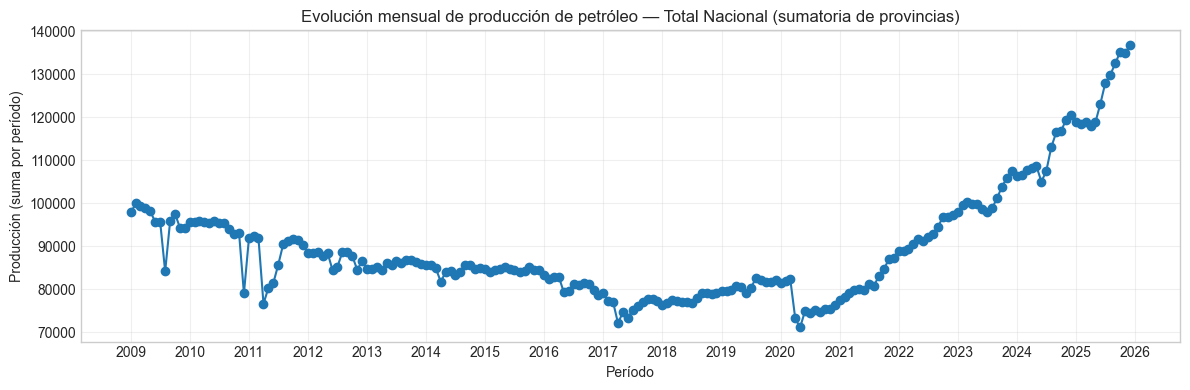

In [50]:
if df_model["periodo"].notna().any() and df_model["produccion"].notna().any():

    ts = (
        df_model
        .dropna(subset=["periodo", "produccion"])
        .groupby("periodo", as_index=False)["produccion"]
        .sum()
        .sort_values("periodo")
    )

    # Convertir periodo a datetime para graficar bien
    ts["periodo_dt"] = pd.to_datetime(ts["periodo"].astype(str), format="%Y-%m")

    # Detectar último período sospechosamente bajo
    excluir_ultimo = False

    if len(ts) >= 2:
        ultimo_valor = ts.iloc[-1]["produccion"]
        penultimo_valor = ts.iloc[-2]["produccion"]
        ratio = ultimo_valor / penultimo_valor if penultimo_valor else None

        if ratio is not None and ratio < 0.5:
            excluir_ultimo = True
            print(
                f"Advertencia: se excluye el último período "
                f"({ts.iloc[-1]['periodo']}) porque parece incompleto. "
                f"Representa {ratio:.1%} del período anterior."
            )

    ts_plot = ts.iloc[:-1].copy() if excluir_ultimo else ts.copy()

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        ts_plot["periodo_dt"],
        ts_plot["produccion"],
        marker="o",
        linewidth=1.5
    )

    ax.set_title("Evolución mensual de producción de petróleo — Total Nacional (sumatoria de provincias)")
    ax.set_xlabel("Período")
    ax.set_ylabel("Producción (suma por período)")

    # Mostrar una etiqueta por año
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Marcas menores cada 3 meses, sin texto
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("No hay columnas suficientes para serie temporal.")

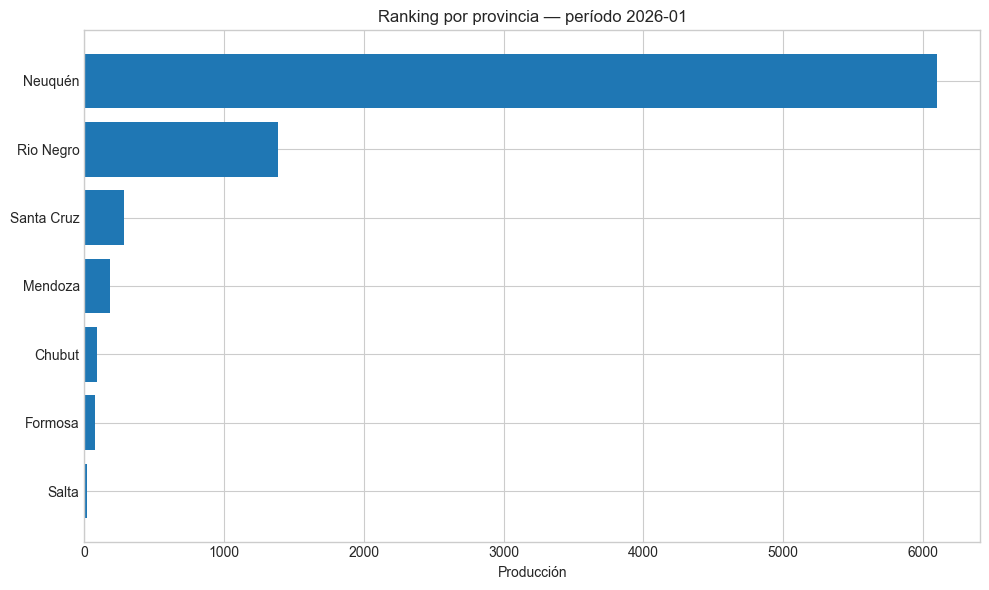

In [16]:
if df_model["agrupador_nombre"].notna().any() and df_model["produccion"].notna().any():
    latest_period = df_model["periodo"].max()
    ranking = (
        df_model[df_model["periodo"] == latest_period]
        .groupby("agrupador_nombre", as_index=False)["produccion"]
        .sum()
        .sort_values("produccion", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(ranking["agrupador_nombre"], ranking["produccion"])
    ax.invert_yaxis()
    ax.set_title(f"Ranking por {agrupador_tipo} — período {latest_period}")
    ax.set_xlabel("Producción")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas suficientes para ranking.")

Advertencia: se usa 2025-12 porque el último período (2026-01) parece incompleto.


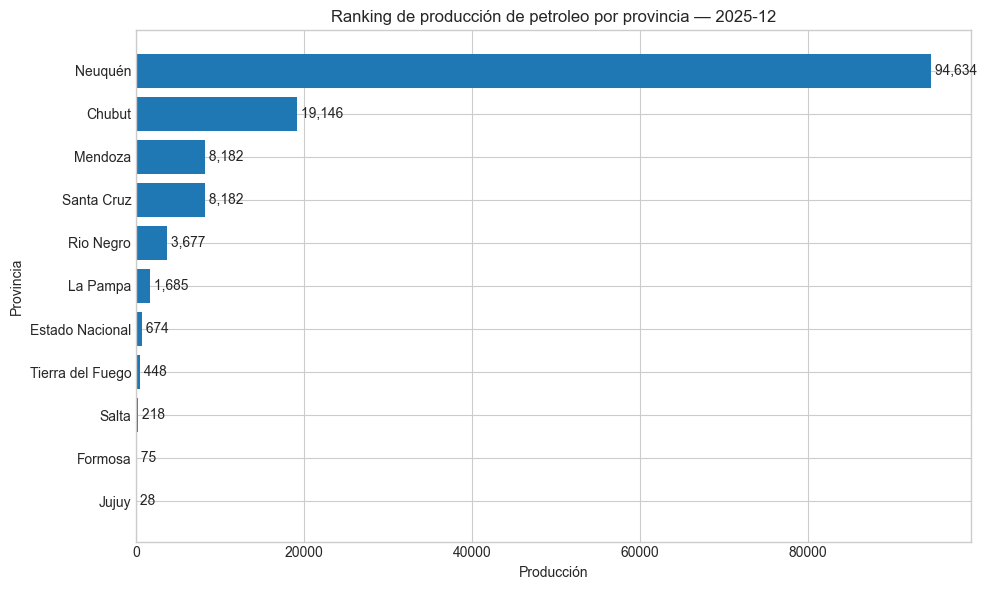

In [ ]:
if df_model["agrupador_nombre"].notna().any() and df_model["produccion"].notna().any():

    ts = (
        df_model
        .dropna(subset=["periodo", "produccion"])
        .groupby("periodo", as_index=False)["produccion"]
        .sum()
        .sort_values("periodo")
    )

    # Detectar último período sospechosamente bajo
    latest_period = ts.iloc[-1]["periodo"]

    if len(ts) >= 2:
        ultimo_valor = ts.iloc[-1]["produccion"]
        penultimo_valor = ts.iloc[-2]["produccion"]
        ratio = ultimo_valor / penultimo_valor if penultimo_valor else 1

        if ratio < 0.5:
            latest_period = ts.iloc[-2]["periodo"]
            print(
                f"Advertencia: se usa {latest_period} porque el último período "
                f"({ts.iloc[-1]['periodo']}) parece incompleto."
            )

    ranking = (
        df_model[df_model["periodo"] == latest_period]
        .dropna(subset=["agrupador_nombre", "produccion"])
        .groupby("agrupador_nombre", as_index=False)["produccion"]
        .sum()
        .sort_values("produccion", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(ranking["agrupador_nombre"], ranking["produccion"])
    ax.invert_yaxis()

    ax.set_title(
        f"Ranking de producción de {producto} por {agrupador_tipo} — {latest_period}"
    )
    ax.set_xlabel("Producción")
    ax.set_ylabel(agrupador_tipo.capitalize())

    plt.tight_layout()
    plt.show()

else:
    print("No hay columnas suficientes para ranking.")

Advertencia: se excluye el último período (2026-01) porque parece incompleto. Representa 5.9% del período anterior.


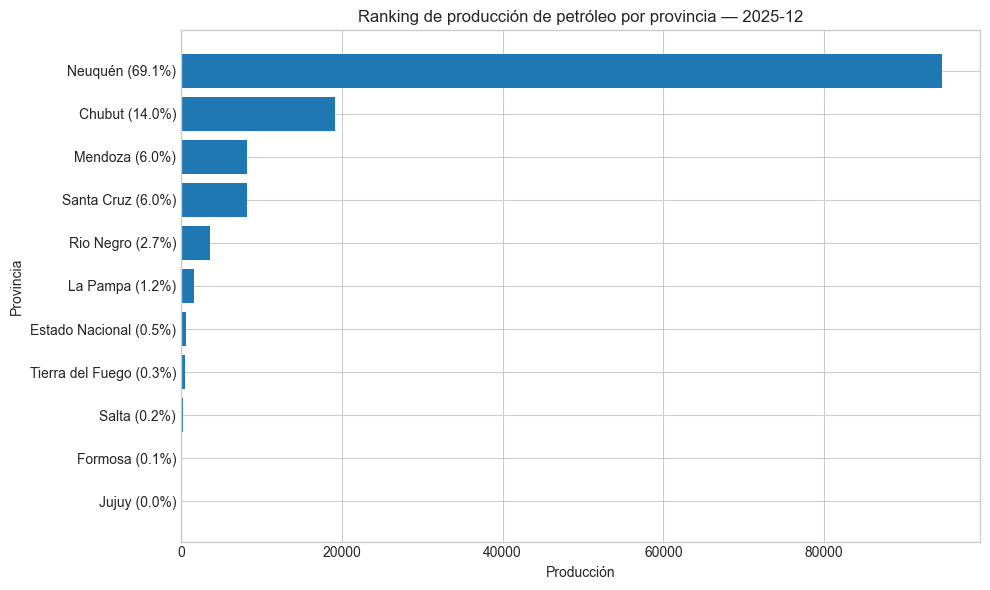

Período analizado: 2025-12
Total producido en el período: 136,948.47
Principal provincia: Neuquén
Producción principal: 94,633.56
Participación principal: 69.10%


,agrupador_nombre,produccion,participacion_pct
6,Neuquén,94633.56,69.10
0,Chubut,19146.44,13.98
5,Mendoza,8182.10,5.97
9,Santa Cruz,8181.51,5.97
7,Rio Negro,3677.40,2.69
4,La Pampa,1685.28,1.23
1,Estado Nacional,673.94,0.49
10,Tierra del Fuego,447.82,0.33
8,Salta,217.69,0.16
2,Formosa,74.86,0.05



Comparación contra período anterior: 2025-11 → 2025-12


,agrupador_nombre,produccion_actual,produccion_anterior,variacion_abs,variacion_pct
6,Neuquén,94633.56,92532.95,2100.61,2.27
0,Chubut,19146.44,18392.01,754.43,4.10
5,Mendoza,8182.10,8172.45,9.65,0.12
9,Santa Cruz,8181.51,9264.56,-1083.05,-11.69
7,Rio Negro,3677.40,3375.77,301.63,8.94
4,La Pampa,1685.28,1721.49,-36.22,-2.10
1,Estado Nacional,673.94,691.39,-17.45,-2.52
10,Tierra del Fuego,447.82,406.79,41.02,10.08
8,Salta,217.69,217.02,0.67,0.31
2,Formosa,74.86,74.57,0.29,0.39


In [66]:
def format_number(value, decimals=0):
    return f"{value:.{decimals}f}".replace(".", ",")
# ============================================================
# Ranking de producción por agrupador
# ============================================================

if df_model["agrupador_nombre"].notna().any() and df_model["produccion"].notna().any():

    # --------------------------------------------------------
    # 1. Serie total por período para detectar último dato válido
    # --------------------------------------------------------
    ts = (
        df_model
        .dropna(subset=["periodo", "produccion"])
        .groupby("periodo", as_index=False)["produccion"]
        .sum()
        .sort_values("periodo")
    )

    latest_period = ts.iloc[-1]["periodo"]
    excluded_period = None

    # --------------------------------------------------------
    # 2. Detectar si el último período parece incompleto
    # --------------------------------------------------------
    if len(ts) >= 2:
        ultimo_valor = ts.iloc[-1]["produccion"]
        penultimo_valor = ts.iloc[-2]["produccion"]

        ratio = ultimo_valor / penultimo_valor if penultimo_valor else 1

        if ratio < 0.5:
            excluded_period = latest_period
            latest_period = ts.iloc[-2]["periodo"]

            print(
                f"Advertencia: se excluye el último período ({excluded_period}) "
                f"porque parece incompleto. Representa {ratio:.1%} del período anterior."
            )

    # --------------------------------------------------------
    # 3. Filtrar datos del período elegido
    # --------------------------------------------------------
    df_periodo = (
        df_model[df_model["periodo"] == latest_period]
        .dropna(subset=["agrupador_nombre", "produccion"])
        .copy()
    )

    total_periodo = df_periodo["produccion"].sum()

    # --------------------------------------------------------
    # 4. Armar ranking
    # --------------------------------------------------------
    ranking = (
        df_periodo
        .groupby("agrupador_nombre", as_index=False)["produccion"]
        .sum()
        .sort_values("produccion", ascending=False)
    )

    ranking["participacion_pct"] = (
        ranking["produccion"] / total_periodo * 100
    )

    # Label para mostrar nombre + porcentaje
    ranking["label"] = ranking.apply(
        lambda row: f"{row['agrupador_nombre']} ({row['participacion_pct']:.1f}%)",
        axis=1
    )

    # --------------------------------------------------------
    # 5. Gráfico de barras horizontal
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        ranking["label"],
        ranking["produccion"]
    )

    ax.invert_yaxis()

    producto_labels = {
        "petroleo": "petróleo",
        "petróleo": "petróleo",
        "gas": "gas"
    }

    agrupador_labels = {
        "provincia": "provincia",
        "cuenca": "cuenca",
        "empresa": "empresa"
    }

    producto_label = producto_labels.get(producto, producto)
    agrupador_label = agrupador_labels.get(agrupador_tipo, agrupador_tipo)

    ax.set_title(
        f"Ranking de producción de {producto_label} por {agrupador_label} — {latest_period}"
    )

    ax.set_xlabel("Producción")
    ax.set_ylabel(agrupador_label.capitalize())

    # Etiquetas con valores al final de cada barra
    # for i, value in enumerate(ranking["produccion"]):
    #     ax.text(
    #         value,
    #         i,
    #         f" {format_number(value, decimals=0)}",
    #         va="center"
    #     )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 6. Tabla resumen del ranking
    # --------------------------------------------------------
    ranking_display = ranking[
        ["agrupador_nombre", "produccion", "participacion_pct"]
    ].copy()

    ranking_display["produccion"] = ranking_display["produccion"].round(2)
    ranking_display["participacion_pct"] = ranking_display["participacion_pct"].round(2)

    print(f"Período analizado: {latest_period}")
    print(f"Total producido en el período: {total_periodo:,.2f}")
    print(f"Principal {agrupador_label}: {ranking.iloc[0]['agrupador_nombre']}")
    print(f"Producción principal: {ranking.iloc[0]['produccion']:,.2f}")
    print(f"Participación principal: {ranking.iloc[0]['participacion_pct']:.2f}%")

    display(ranking_display)

    # --------------------------------------------------------
    # 7. Comparación contra período anterior
    # --------------------------------------------------------
    periodos_validos = ts["periodo"].tolist()

    if latest_period in periodos_validos:
        idx_actual = periodos_validos.index(latest_period)

        if idx_actual > 0:
            periodo_anterior = periodos_validos[idx_actual - 1]

            actual = (
                df_model[df_model["periodo"] == latest_period]
                .dropna(subset=["agrupador_nombre", "produccion"])
                .groupby("agrupador_nombre", as_index=False)["produccion"]
                .sum()
                .rename(columns={"produccion": "produccion_actual"})
            )

            anterior = (
                df_model[df_model["periodo"] == periodo_anterior]
                .dropna(subset=["agrupador_nombre", "produccion"])
                .groupby("agrupador_nombre", as_index=False)["produccion"]
                .sum()
                .rename(columns={"produccion": "produccion_anterior"})
            )

            comparacion = actual.merge(
                anterior,
                on="agrupador_nombre",
                how="left"
            )

            comparacion["variacion_abs"] = (
                comparacion["produccion_actual"] -
                comparacion["produccion_anterior"]
            )

            comparacion["variacion_pct"] = (
                comparacion["variacion_abs"] /
                comparacion["produccion_anterior"] *
                100
            )

            comparacion = (
                comparacion
                .sort_values("produccion_actual", ascending=False)
            )

            comparacion_display = comparacion.copy()

            comparacion_display["produccion_actual"] = (
                comparacion_display["produccion_actual"].round(2)
            )
            comparacion_display["produccion_anterior"] = (
                comparacion_display["produccion_anterior"].round(2)
            )
            comparacion_display["variacion_abs"] = (
                comparacion_display["variacion_abs"].round(2)
            )
            comparacion_display["variacion_pct"] = (
                comparacion_display["variacion_pct"].round(2)
            )

            print()
            print(f"Comparación contra período anterior: {periodo_anterior} → {latest_period}")

            display(comparacion_display)

        else:
            print("No hay período anterior disponible para comparar.")

else:
    print("No hay columnas suficientes para ranking.")

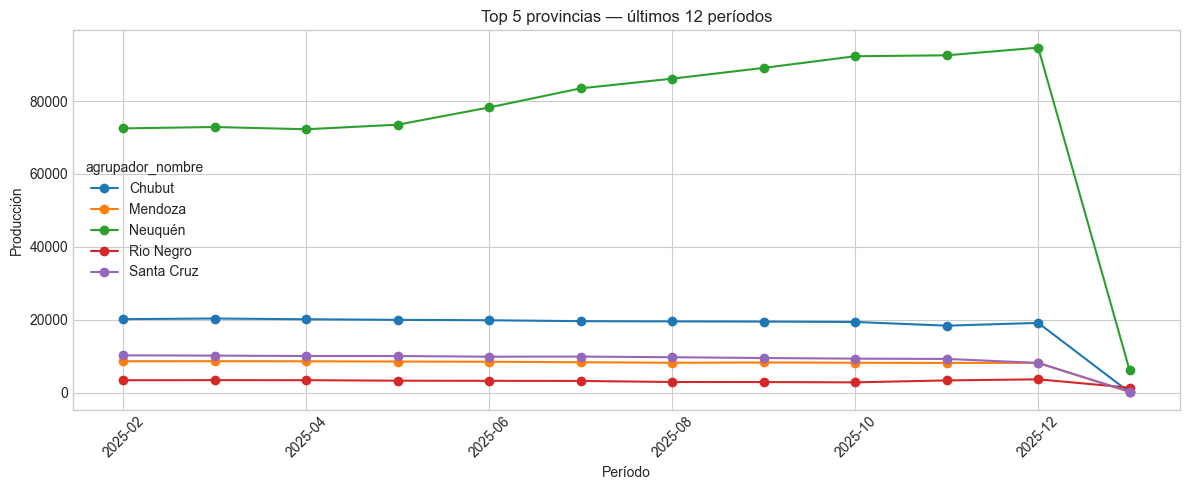

In [17]:
# Comparación entre agrupadores en los últimos 12 períodos
if df_model["periodo"].notna().any():
    recent_periods = sorted(df_model["periodo"].dropna().unique())[-12:]
    top_groups = (
        df_model[df_model["periodo"] == df_model["periodo"].max()]
        .groupby("agrupador_nombre")["produccion"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    compare = df_model[
        df_model["periodo"].isin(recent_periods)
        & df_model["agrupador_nombre"].isin(top_groups)
    ]

    pivot = compare.pivot_table(
        index="periodo",
        columns="agrupador_nombre",
        values="produccion",
        aggfunc="sum",
    ).sort_index()

    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        pivot.plot(ax=ax, marker="o")
        ax.set_title(f"Top 5 {agrupador_tipo}s — últimos 12 períodos")
        ax.set_xlabel("Período")
        ax.set_ylabel("Producción")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Pivot vacío para comparación.")
else:
    print("Sin columna periodo para comparación.")

In [68]:
print(df_model["periodo"].dtype)
print(df_model["periodo"].dropna().sort_values().head(20))
print(df_model["periodo"].dropna().sort_values().tail(20))

str
0     2009-01
12    2009-01
11    2009-01
10    2009-01
8     2009-01
7     2009-01
9     2009-01
5     2009-01
4     2009-01
3     2009-01
2     2009-01
1     2009-01
6     2009-01
20    2009-02
25    2009-02
24    2009-02
23    2009-02
21    2009-02
19    2009-02
22    2009-02
Name: periodo, dtype: str
2477    2025-11
2476    2025-11
2497    2025-12
2496    2025-12
2495    2025-12
2494    2025-12
2493    2025-12
2487    2025-12
2491    2025-12
2490    2025-12
2489    2025-12
2488    2025-12
2492    2025-12
2503    2026-01
2498    2026-01
2499    2026-01
2500    2026-01
2501    2026-01
2502    2026-01
2504    2026-01
Name: periodo, dtype: str


Advertencia: se excluye el último período (2026-01) porque parece incompleto. Representa 5.9% del período anterior.


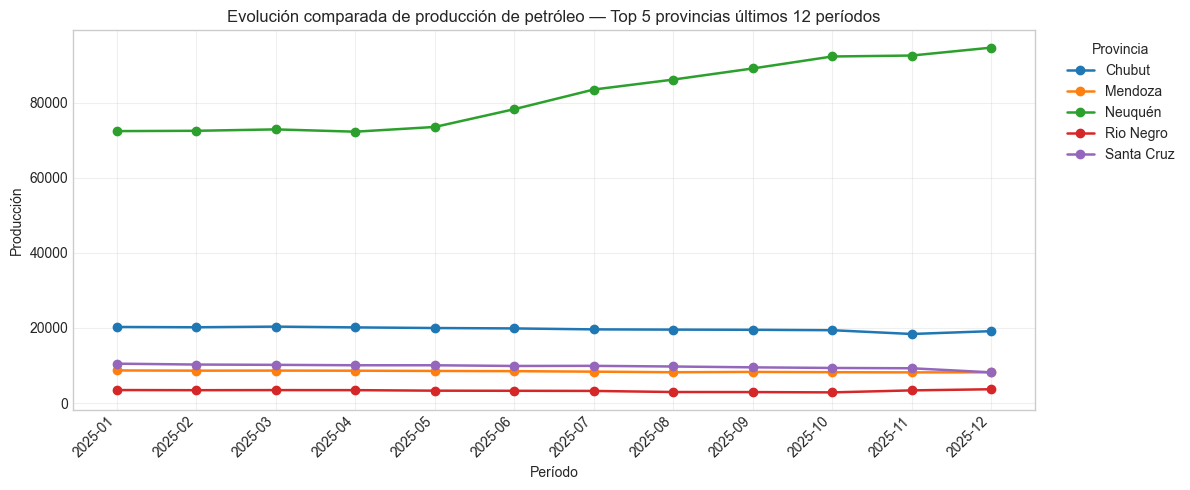

Período inicial: 2025-01
Período final: 2025-12
Top 5 calculado según el período: 2025-12


agrupador_nombre,Chubut,Mendoza,Neuquén,Rio Negro,Santa Cruz
periodo,,,,,
2025-01,20259.32,8683.48,72408.73,3463.50,10487.76
2025-02,20184.09,8627.95,72493.82,3427.18,10257.46
2025-03,20352.02,8643.13,72868.53,3451.00,10176.13
2025-04,20149.20,8616.61,72255.99,3436.65,10068.29
2025-05,19980.34,8554.68,73516.32,3299.36,10064.07
2025-06,19873.56,8493.45,78249.89,3266.98,9878.07
2025-07,19619.25,8360.69,83480.05,3232.23,9909.37
2025-08,19557.83,8205.94,86129.51,2940.18,9735.65
2025-09,19509.61,8292.53,89088.12,2925.97,9511.84


In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# Comparación entre Top 5 agrupadores en últimos 12 períodos válidos
# ============================================================

if (
    df_model["periodo"].notna().any()
    and df_model["agrupador_nombre"].notna().any()
    and df_model["produccion"].notna().any()
):

    # --------------------------------------------------------
    # 1. Serie total por período
    # --------------------------------------------------------
    ts = (
        df_model
        .dropna(subset=["periodo", "produccion"])
        .groupby("periodo", as_index=False)["produccion"]
        .sum()
        .sort_values("periodo")
    )

    periodos_validos = ts["periodo"].tolist()

    # --------------------------------------------------------
    # 2. Detectar último período incompleto
    # --------------------------------------------------------
    if len(ts) >= 2:
        ultimo_periodo = ts.iloc[-1]["periodo"]
        ultimo_valor = ts.iloc[-1]["produccion"]
        penultimo_valor = ts.iloc[-2]["produccion"]

        ratio = ultimo_valor / penultimo_valor if penultimo_valor else 1

        if ratio < 0.5:
            print(
                f"Advertencia: se excluye el último período ({ultimo_periodo}) "
                f"porque parece incompleto. Representa {ratio:.1%} del período anterior."
            )
            periodos_validos = periodos_validos[:-1]

    # --------------------------------------------------------
    # 3. Últimos 12 períodos válidos
    # --------------------------------------------------------
    recent_periods = periodos_validos[-12:]

    if len(recent_periods) == 0:
        print("No hay períodos válidos para graficar.")

    else:
        latest_valid_period = recent_periods[-1]

        # ----------------------------------------------------
        # 4. Top 5 según último período válido
        # ----------------------------------------------------
        top_groups = (
            df_model[df_model["periodo"] == latest_valid_period]
            .dropna(subset=["agrupador_nombre", "produccion"])
            .groupby("agrupador_nombre")["produccion"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
            .index
        )

        # ----------------------------------------------------
        # 5. Filtrar comparación
        # ----------------------------------------------------
        compare = df_model[
            df_model["periodo"].isin(recent_periods)
            & df_model["agrupador_nombre"].isin(top_groups)
        ].copy()

        pivot = (
            compare
            .pivot_table(
                index="periodo",
                columns="agrupador_nombre",
                values="produccion",
                aggfunc="sum"
            )
            .reindex(recent_periods)
        )

        # ----------------------------------------------------
        # 6. Graficar
        # ----------------------------------------------------
        if not pivot.empty:

            fig, ax = plt.subplots(figsize=(12, 5))

            pivot.plot(
                ax=ax,
                marker="o",
                linewidth=1.8
            )

            producto_labels = {
                "petroleo": "petróleo",
                "petróleo": "petróleo",
                "gas": "gas"
            }

            agrupador_labels = {
                "provincia": "provincias",
                "cuenca": "cuencas",
                "empresa": "empresas"
            }

            producto_label = producto_labels.get(producto, producto)
            agrupador_label = agrupador_labels.get(agrupador_tipo, agrupador_tipo)

            ax.set_title(
                f"Evolución comparada de producción de {producto_label} — "
                f"Top 5 {agrupador_label} últimos 12 períodos"
            )

            ax.set_xlabel("Período")
            ax.set_ylabel("Producción")

            # Como son solo 12 períodos, se pueden mostrar todos
            ax.set_xticks(range(len(pivot.index)))
            ax.set_xticklabels(pivot.index, rotation=45, ha="right")

            ax.grid(True, alpha=0.3)

            ax.legend(
                title=agrupador_tipo.capitalize(),
                bbox_to_anchor=(1.02, 1),
                loc="upper left"
            )

            plt.tight_layout()
            plt.show()

            print(f"Período inicial: {recent_periods[0]}")
            print(f"Período final: {recent_periods[-1]}")
            print(f"Top 5 calculado según el período: {latest_valid_period}")

            display(pivot.round(2))

        else:
            print("Pivot vacío para comparación.")

else:
    print("No hay columnas suficientes para comparación.")

## 15. Conclusiones (completar tras ejecutar la notebook)

In [71]:
print("=" * 70)
print("CONCLUSIONES EXPLORATORIAS")
print("=" * 70)

print("\n1) Recursos útiles para el MVP")
for _, row in df_mvp.iterrows():
    flag = "✓" if row["found"] else "✗"
    print(f"   {flag} {row['mvp_target']}: {row['name']}")

print("\n2) Columnas reales del recurso descargado")
print(f"   {list(df_raw.columns)}")

print("\n3) Problemas de limpieza detectados")
issues = []
if df_raw.isna().any().any():
    issues.append(f"Valores nulos en: {df_raw.columns[df_raw.isna().any()].tolist()}")
if any(str(c).startswith("\ufeff") for c in df_raw.columns):
    issues.append("Posible BOM en encabezados (usar encoding='utf-8-sig')")
if not issues:
    issues.append("Sin problemas graves evidentes en esta muestra")
for item in issues:
    print(f"   - {item}")

print("\n4) Datos recomendados para primer dashboard Streamlit")
print("   - Producción promedio diaria por provincia/cuenca/empresa (CSV mensuales)")
print("   - Series SESCO + Tight/Shale por dimensión para comparar convencional vs no convencional")
print(f"   - Recurso analizado hoy: {source_resource_name}")

print("\n5) Dudas abiertas")
print("   - Unidades exactas y definiciones oficiales de cada columna de producción")
print("   - Solapamiento entre recursos 'promedio diaria' y 'SESCO + Tight y Shale'")
print("   - Frecuencia de actualización y lag de publicación")
print("   - Tratamiento de 'Estado Nacional' y categorías administrativas especiales")
print("   - Estrategia de unión temporal entre series anteriores a 2009 y posteriores")

CONCLUSIONES EXPLORATORIAS

1) Recursos útiles para el MVP
   ✓ petroleo_provincia: Producción de petróleo promedio diaria por provincia
   ✓ gas_provincia: Producción de gas promedio diaria por provincia
   ✓ petroleo_cuenca: Producción de petróleo promedio diaria por cuenca
   ✓ gas_cuenca: Producción de gas promedio diaria por cuenca
   ✓ petroleo_empresa: Producción de petróleo promedio diaria por empresa
   ✓ gas_empresa: Producción de gas promedio diaria por empresa

2) Columnas reales del recurso descargado
   ['anio', 'mes', 'indice_tiempo', 'provincia', 'produccion_petroleo_promedio_dia_m3']

3) Problemas de limpieza detectados
   - Sin problemas graves evidentes en esta muestra

4) Datos recomendados para primer dashboard Streamlit
   - Producción promedio diaria por provincia/cuenca/empresa (CSV mensuales)
   - Series SESCO + Tight/Shale por dimensión para comparar convencional vs no convencional
   - Recurso analizado hoy: Producción de petróleo promedio diaria por provinci